<a href="https://colab.research.google.com/github/Umang-Gisma/M505D/blob/main/GB_for_Bank_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas            as pd
import numpy             as np
import seaborn           as sns
import plotly.express    as px
import matplotlib.pyplot as plt

from imblearn.over_sampling    import SMOTE
from sklearn.preprocessing     import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler
from sklearn.model_selection   import train_test_split, GridSearchCV
from sklearn.linear_model      import LogisticRegression
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics           import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics           import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

In [11]:
APPLY_SMOTE     = False
APPLY_SCALER    = False
SHOW_CONFMATRIX = False

In [12]:
df = pd.read_csv("/content/bank_data (1).csv")
print("Shape of the dataset:", df.shape)
df.head(3)

Shape of the dataset: (10000, 13)


,id,last_name,credit_score,country,gender,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros,retained
0,15634602,Hargrave,619,Switzerland,f,42,2,0.00,1,1,1,101348.88,0
1,15647311,Hill,608,Austria,f,41,1,83807.86,1,0,1,112542.58,1
2,15619304,Onio,502,Switzerland,f,42,8,159660.80,3,1,0,113931.57,0


In [13]:
df["churn"] = df["retained"].apply(lambda x: 1 if x==0 else 0)

df.drop(["id", "last_name", "retained"], axis=1, inplace=True)

df = df.join(pd.get_dummies(df['gender']))
df.drop("gender", axis=1, inplace=True)

df = df.join(pd.get_dummies(df['country']))
df.drop("country", axis=1, inplace=True)

In [14]:
y = df['churn'].to_numpy()
y = y.astype(float)

df.drop('churn', inplace=True, axis=1)
feature_names = df.columns.to_list()

X = df.values
X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
if APPLY_SCALER:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
else:
    X_train_scaled = X_train


In [16]:
if APPLY_SMOTE:
    sm = SMOTE()
    X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
else:
    X_res = X_train_scaled
    y_res = y_train

## Gradient Boosting Classifier

In [17]:
rf_clf = GradientBoostingClassifier(random_state=42)

# Training
rf_clf.fit(X_res, y_res)

if APPLY_SCALER:
    X_test_scaled = scaler.transform(X_test)
else:
    X_test_scaled = X_test

# Prediction
y_pred = rf_clf.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

if SHOW_CONFMATRIX:
    ConfusionMatrixDisplay.from_estimator(rf_clf, X_test_scaled, y_test)

              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92      1607
         1.0       0.74      0.47      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



## Hyperparameter Tunning for Gradient Boosting

In [18]:
# Define parameter grid for Random Forest
param_grid = {
    # "n_estimators": [50, 100, 500],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.5, 0.75, 1.0],
    "criterion": ["friedman_mse", "squared_error"],
    "max_depth": [3, 5, 7],
}

# Initialize base model
gb = GradientBoostingClassifier(random_state=42)

# GridSearch with cross-validation
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=3
)

# Train on resampled training data
grid_search.fit(X_res, y_res)

# Get best model
best_gb = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Scaling (NOTE: not required for RandomForest, but kept for compatibility with your pipeline)
if APPLY_SCALER:
    X_test_scaled = scaler.transform(X_test)  # avoid data leakage
else:
    X_test_scaled = X_test

# Prediction with best model
y_pred = best_gb.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

if SHOW_CONFMATRIX:
    ConfusionMatrixDisplay.from_estimator(best_gb, X_test_scaled, y_test)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'criterion': 'squared_error', 'learning_rate': 0.2, 'max_depth': 3, 'subsample': 0.75}
Best CV Score: 0.6043915384200356
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      1607
         1.0       0.74      0.51      0.61       393

    accuracy                           0.87      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



## RF Feature Importance

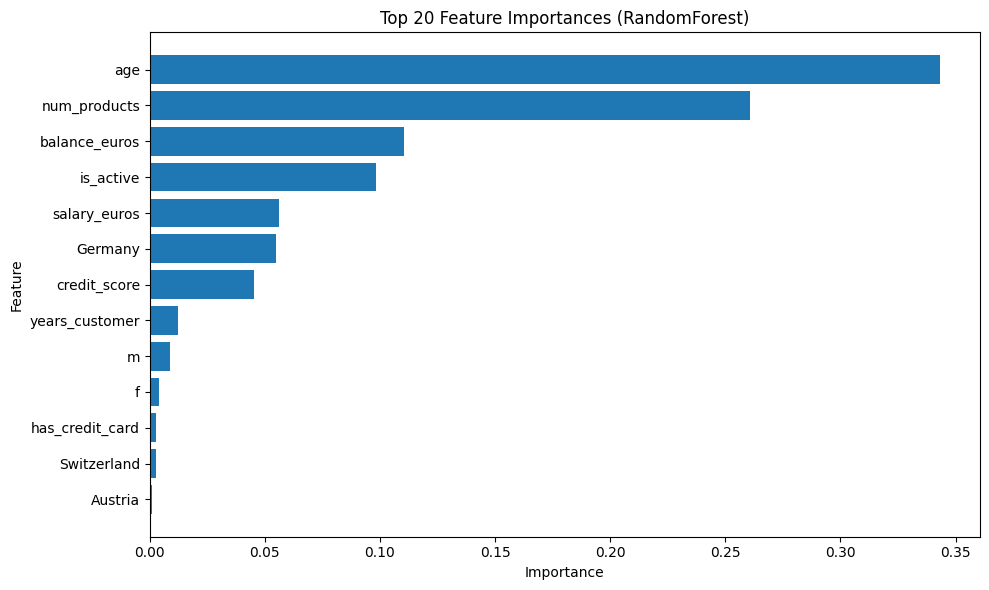

,feature,importance
0,age,0.343469
1,num_products,0.260618
2,balance_euros,0.110522
3,is_active,0.098167
4,salary_euros,0.055918
5,Germany,0.055042
6,credit_score,0.045264
7,years_customer,0.012175
8,m,0.008582
9,f,0.004050


In [19]:
# --- Feature Importance (RandomForest) ---

importances = best_gb.feature_importances_

fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Show top-K features
TOP_K = 20
top_fi = fi_df.head(TOP_K).iloc[::-1]  # reverse for nicer barh order

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {TOP_K} Feature Importances (RandomForest)")
plt.tight_layout()
plt.show()

# Optional: print table
display(fi_df.head(TOP_K))